# Phase 1: Preprocessing

## 1.1 Libraries

| Library | Purpose |
|---|---|
| **pandas** | Data manipulation and analysis |
| **numpy** | Numerical computations |
| **seaborn / matplotlib** | Statistical visualization |
| **StandardScaler** | Standardize features (μ=0, σ=1) |
| **PowerTransformer** | Reduce skewness via Yeo-Johnson |
| **VarianceThreshold** | Remove near-zero variance features |

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold

## 1.2 Load Datasets

In [2]:
application_record = pd.read_csv('application_record.csv')
application_record.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [3]:
application_record.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

### Application Dataset — Column Descriptions

| Column | Description |
|---|---|
| **ID** | Unique client identifier |
| **CODE_GENDER** | M = Male, F = Female |
| **FLAG_OWN_CAR** | Y/N — owns a car |
| **FLAG_OWN_REALTY** | Y/N — owns real estate |
| **CNT_CHILDREN** | Number of children |
| **AMT_INCOME_TOTAL** | Total annual income |
| **NAME_INCOME_TYPE** | Income source (Working, Pensioner, etc.) |
| **NAME_EDUCATION_TYPE** | Highest education level |
| **NAME_FAMILY_STATUS** | Marital status |
| **NAME_HOUSING_TYPE** | Housing situation |
| **DAYS_BIRTH** | Age in days (negative) |
| **DAYS_EMPLOYED** | Days employed (negative); positive = unemployed |
| **FLAG_MOBIL** | Has mobile phone (always 1 → dropped later) |
| **FLAG_WORK_PHONE** | Has work phone |
| **FLAG_PHONE** | Has personal phone |
| **FLAG_EMAIL** | Provided email |
| **OCCUPATION_TYPE** | Job type |
| **CNT_FAM_MEMBERS** | Total family members |

In [4]:
credit_record = pd.read_csv('credit_record.csv')
credit_record.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [5]:
credit_record.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 25.0 MB


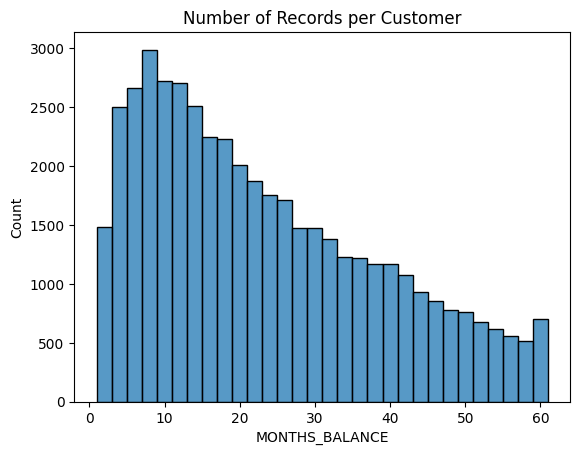

In [6]:
months_count = credit_record.groupby('ID')['MONTHS_BALANCE'].count()
sns.histplot(months_count, bins=30)
plt.title("Number of Records per Customer")
plt.show()

### Credit Record — Column Descriptions

| Column | Description |
|---|---|
| **ID** | Client identifier (used for merge) |
| **MONTHS_BALANCE** | Month offset from application (0 = current, -1 = last month) |
| **STATUS** | Payment status: 0–5 = days overdue, C = closed, X = no loan |

**Target definition:** A customer is **bad (1)** if they were ever 60+ days overdue (STATUS in 2, 3, 4, 5).

## 1.3 Build Target Variable

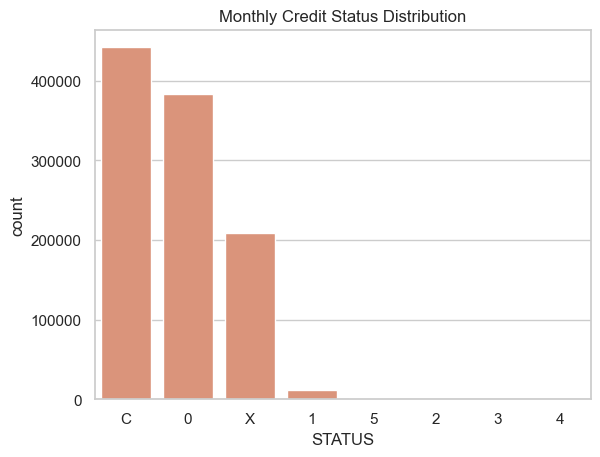

In [7]:
sns.set_theme(palette="flare",style="whitegrid")
sns.countplot(x='STATUS', data=credit_record, order=credit_record['STATUS'].value_counts().index)
plt.title("Monthly Credit Status Distribution")
plt.show()

In [8]:
# 1 = bad customer (60+ days overdue at least once), 0 = good
credit_record['Target'] = credit_record['STATUS'].apply(
    lambda x: 1 if x in ['2', '3', '4', '5'] else 0
)

## 1.4 Aggregate Credit History per Customer

We reduce the monthly credit table to **one row per customer** by:
- **Target** → max delinquency flag (if ever bad, customer = bad)
- **RECORD_COUNT** → number of months of credit history (proxy for loyalty)

In [9]:
credit_summary = credit_record.groupby('ID').agg(
    Target=('Target', 'max'),
    RECORD_COUNT=('MONTHS_BALANCE', 'count')
).reset_index()

print(f"Monthly records : {len(credit_record):,}")
print(f"Unique customers: {len(credit_summary):,}")

Monthly records : 1,048,575
Unique customers: 45,985


## 1.5 Merge Datasets

Inner join — keep only customers present in **both** datasets.

In [10]:
df = pd.merge(application_record, credit_summary, on='ID', how='inner')
print(f"Merged dataset shape: {df.shape}")
df.info()

Merged dataset shape: (36457, 20)
<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  str    
 2   FLAG_OWN_CAR         36457 non-null  str    
 3   FLAG_OWN_REALTY      36457 non-null  str    
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  str    
 7   NAME_EDUCATION_TYPE  36457 non-null  str    
 8   NAME_FAMILY_STATUS   36457 non-null  str    
 9   NAME_HOUSING_TYPE    36457 non-null  str    
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL   

## 1.6 Remove Duplicates & Drop ID

**Why duplicates appear after dropping ID:**
The same person may apply multiple times (different IDs) with identical personal data.
After removing the ID column, these rows become exact duplicates.

In [11]:
print(f"Rows before dedup : {len(df):,}")
print(f"Duplicates on ID  : {df.duplicated('ID').sum():,}")

df = df.drop_duplicates('ID', keep='last')  # keep most recent application
df.drop('ID', axis=1, inplace=True)         # ID has no predictive value

df = df.drop_duplicates()                   # remove remaining identical rows
print(f"Rows after  dedup : {len(df):,}")

Rows before dedup : 36,457
Duplicates on ID  : 0
Rows after  dedup : 27,500


## 1.7 Handle Missing Values

In [12]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
OCCUPATION_TYPE    8440
dtype: int64


In [13]:
# OCCUPATION_TYPE: NaN means no occupation info → label as 'Unknown'
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

print("Missing values after fix:", df.isnull().sum().sum())

Missing values after fix: 0


## 1.8 Feature Engineering

We derive meaningful features from raw day-count columns:

| New Feature | Formula | Intuition |
|---|---|---|
| **AGE** | DAYS_BIRTH / -365 | Age in years |
| **UNEMPLOYED** | 1 if DAYS_EMPLOYED > 0 | Flag for unemployment |
| **YEARS_EMPLOYED** | DAYS_EMPLOYED / -365 (0 if unemployed) | Work experience in years |
| **EMPLOYMENT_TO_AGE_RATIO** | YEARS_EMPLOYED / AGE | Career stability signal |
| **INCOME_PER_PERSON** | AMT_INCOME_TOTAL / CNT_FAM_MEMBERS | Real purchasing power |
| **EMPLOYMENT_INCOME_INTERACTION** | YEARS_EMPLOYED × INCOME_PER_PERSON | Financial + career stability |

In [14]:
# Age in years
df['AGE'] = df['DAYS_BIRTH'] / -365

# Employment status & experience
df['UNEMPLOYED']     = (df['DAYS_EMPLOYED'] > 0).astype(int)
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'].apply(lambda x: 0 if x > 0 else x / -365)

# Derived ratios and interactions
df['EMPLOYMENT_TO_AGE_RATIO']       = df['YEARS_EMPLOYED'] / df['AGE']
df['INCOME_PER_PERSON']             = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, 1)
df['EMPLOYMENT_INCOME_INTERACTION'] = df['YEARS_EMPLOYED'] * df['INCOME_PER_PERSON']

# Drop raw day columns (replaced by engineered features)
df.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1, inplace=True)

print("New features added. Shape:", df.shape)

New features added. Shape: (27500, 23)


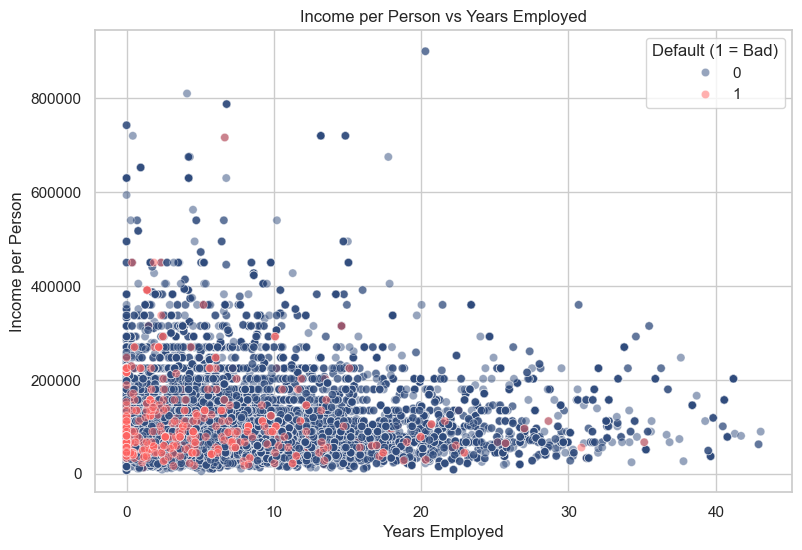

In [15]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="YEARS_EMPLOYED",
    y="INCOME_PER_PERSON",
    hue="Target",
    palette={0:"#2f4b7c", 1:"#ff6361"},
    alpha=0.5
)
plt.title("Income per Person vs Years Employed")
plt.xlabel("Years Employed")
plt.ylabel("Income per Person")
plt.legend(title="Default (1 = Bad)")
plt.show()

We can see that the more years employed the more the client is trusted more.the income is not that important but we can see that the lowe income are mostly bad costumers

## 1.9 Encode Categorical Features

In [16]:
# ── Binary columns ──────────────────────────────────────────
df['CODE_GENDER']    = df['CODE_GENDER'].map({'M': 1, 'F': 0})
df['FLAG_OWN_CAR']   = df['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})
df['FLAG_OWN_REALTY']= df['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})

# ── Ordinal encoding: education has a meaningful order ───────
education_mapping = {
    'Lower secondary'            : 0,
    'Secondary / secondary special': 1,
    'Incomplete higher'          : 2,
    'Higher education'           : 3,
    'Academic degree'            : 4
}
df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map(education_mapping)

# ── One-hot encoding: nominal columns (no natural order) ─────
nominal_cols = ['NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS',
                'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# ── Drop FLAG_MOBIL: single unique value → zero variance ─────
df.drop('FLAG_MOBIL', axis=1, inplace=True)

# ── Ensure clean column names ────────────────────────────────
df.columns = [col.replace(' ', '_').replace('/', '_').replace('-', '_')
              for col in df.columns]

# ── Ensure all columns are numeric ──────────────────────────
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape after encoding: {df.shape}")

Shape after encoding: (27500, 49)


## 1.10 Remove Highly Correlated Features

**Why:** Multicollinearity (correlation > 0.85 between two features) causes:
- Redundant information
- Unstable model coefficients
- Harder to interpret feature importance

We drop one column from each highly-correlated pair.

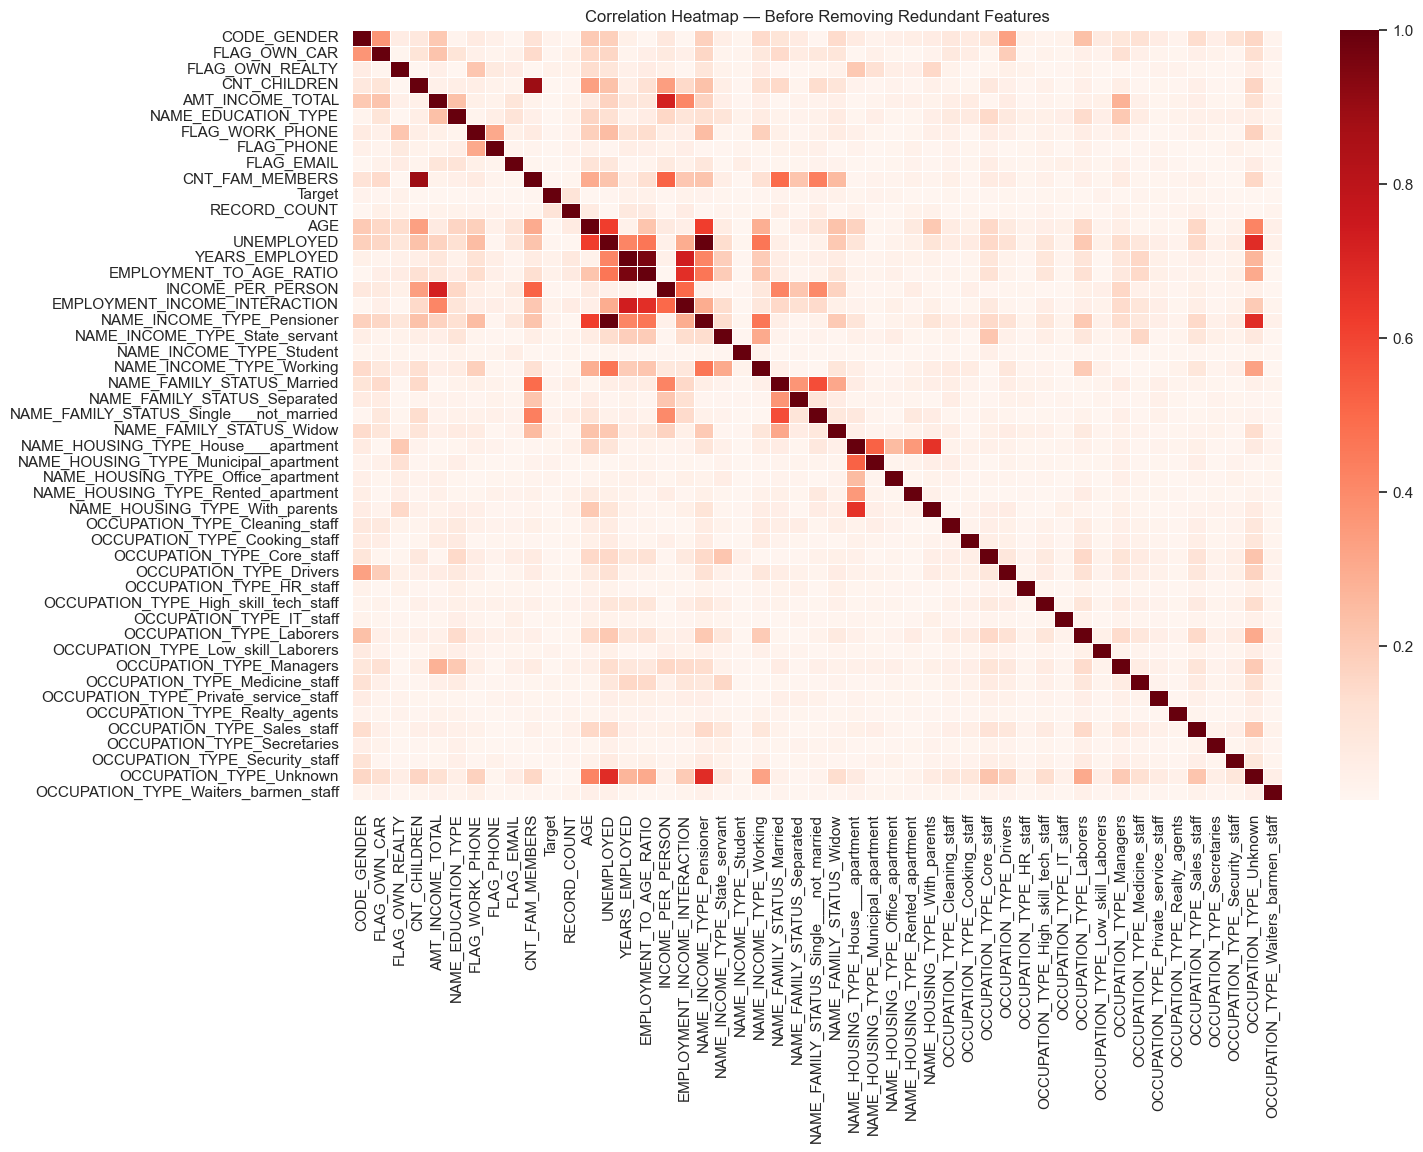

In [17]:
# ── Heatmap BEFORE ──────────────────────────────────────────
plt.figure(figsize=(15, 10))
corr_before = df.corr().abs()
sns.heatmap(corr_before, annot=False, cmap='Reds', linewidths=0.5)
plt.title('Correlation Heatmap — Before Removing Redundant Features')
plt.show()

In [18]:
# ── Top features correlated with Target ─────────────────────
target_corr = df.corr()['Target'].abs().sort_values(ascending=False)
print("Top 10 features correlated with Target:")
print(target_corr.head(11))

Top 10 features correlated with Target:
Target                                1.000000
RECORD_COUNT                          0.104786
FLAG_OWN_REALTY                       0.024758
YEARS_EMPLOYED                        0.023875
EMPLOYMENT_TO_AGE_RATIO               0.023732
NAME_FAMILY_STATUS_Widow              0.023517
EMPLOYMENT_INCOME_INTERACTION         0.022879
OCCUPATION_TYPE_Low_skill_Laborers    0.018195
NAME_INCOME_TYPE_Pensioner            0.017941
CODE_GENDER                           0.017045
NAME_FAMILY_STATUS_Married            0.016795
Name: Target, dtype: float64


In [19]:
# ── Drop one from each pair with correlation > 0.85 ─────────
corr_matrix = df.corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop     = [col for col in upper.columns if any(upper[col] > 0.85)]

df.drop(to_drop, axis=1, inplace=True)
print(f"Dropped columns : {to_drop}")
print(f"Remaining columns: {df.shape[1]}")

Dropped columns : ['CNT_FAM_MEMBERS', 'EMPLOYMENT_TO_AGE_RATIO', 'NAME_INCOME_TYPE_Pensioner']
Remaining columns: 46


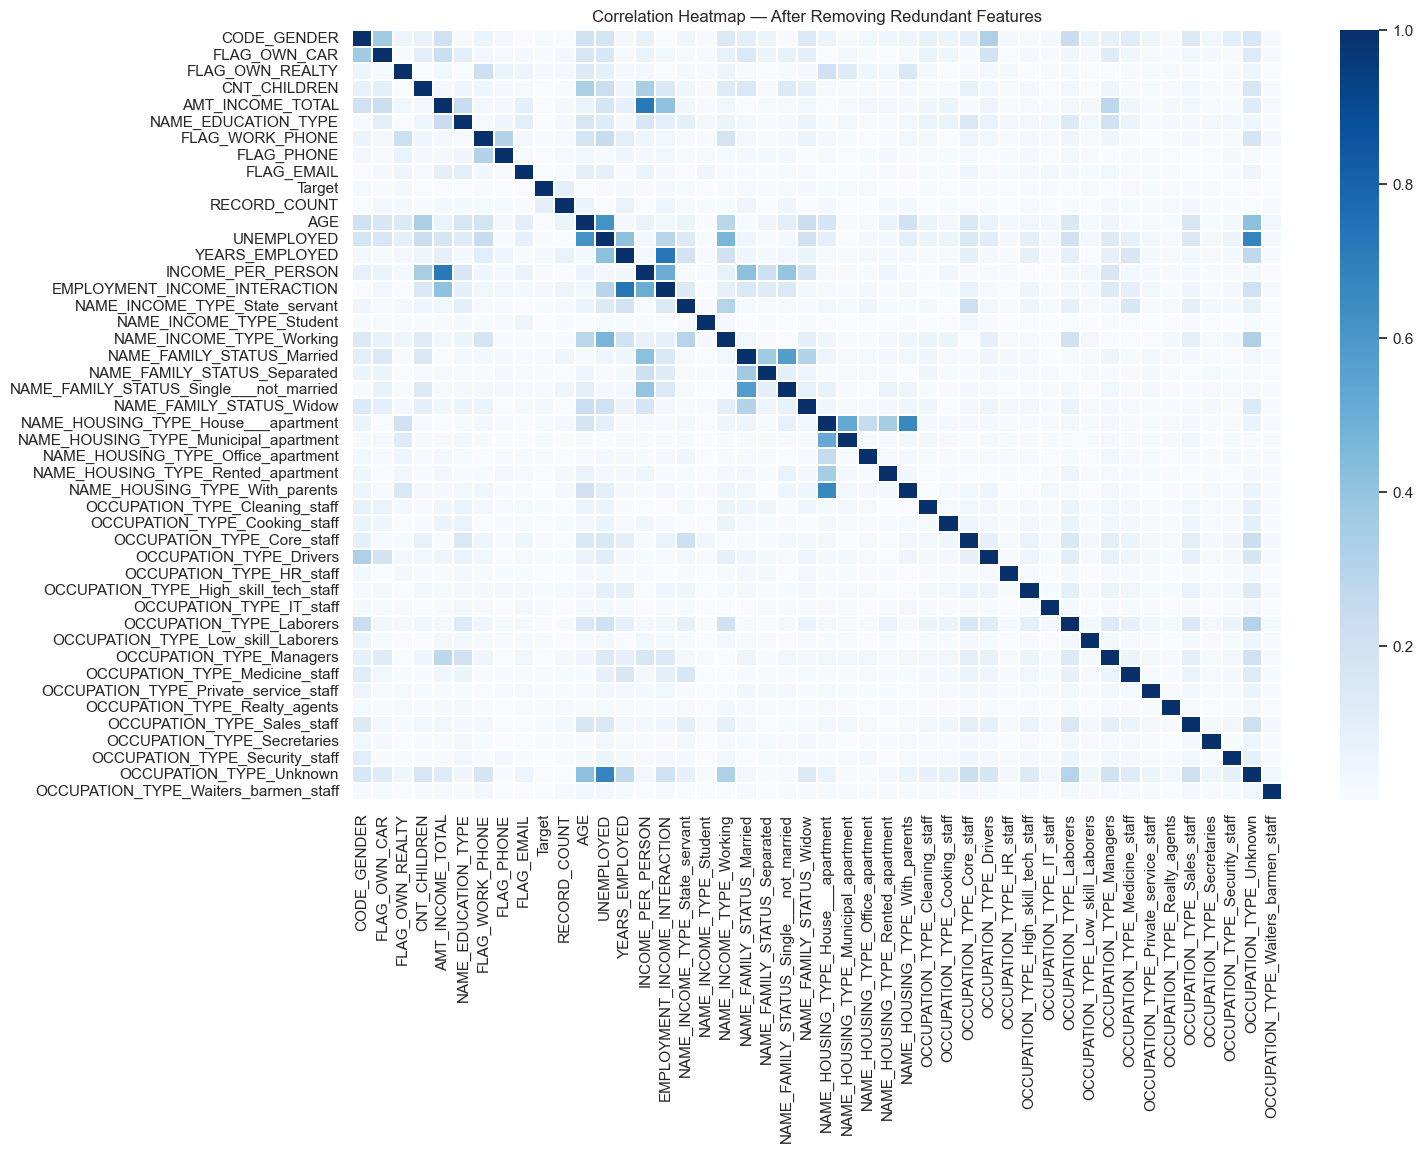

In [20]:
# ── Heatmap AFTER ───────────────────────────────────────────
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr().abs(), annot=False, cmap='Blues', linewidths=0.2)
plt.title('Correlation Heatmap — After Removing Redundant Features')
plt.show()

## 1.11 Handle Skewness

Skewed features hurt linear models and distance-based algorithms.
We apply **Yeo-Johnson** power transformation (handles zeros and negatives).

| Feature | Skew Before | Expected After |
|---|---|---|
| EMPLOYMENT_INCOME_INTERACTION | ~4.15 | ~-0.5 |
| AMT_INCOME_TOTAL | ~2.64 | ~0.0 |
| INCOME_PER_PERSON | ~2.58 | ~0.0 |
| YEARS_EMPLOYED | moderate | ~0.0 |

In [21]:
skew_check_cols = ['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED',
                   'INCOME_PER_PERSON', 'EMPLOYMENT_INCOME_INTERACTION', 'RECORD_COUNT']

print("Skewness BEFORE transformation:")
print(df[skew_check_cols].skew().sort_values(ascending=False).round(3))

Skewness BEFORE transformation:
EMPLOYMENT_INCOME_INTERACTION    4.159
AMT_INCOME_TOTAL                 2.649
INCOME_PER_PERSON                2.587
YEARS_EMPLOYED                   1.756
RECORD_COUNT                     0.621
AGE                              0.172
dtype: float64


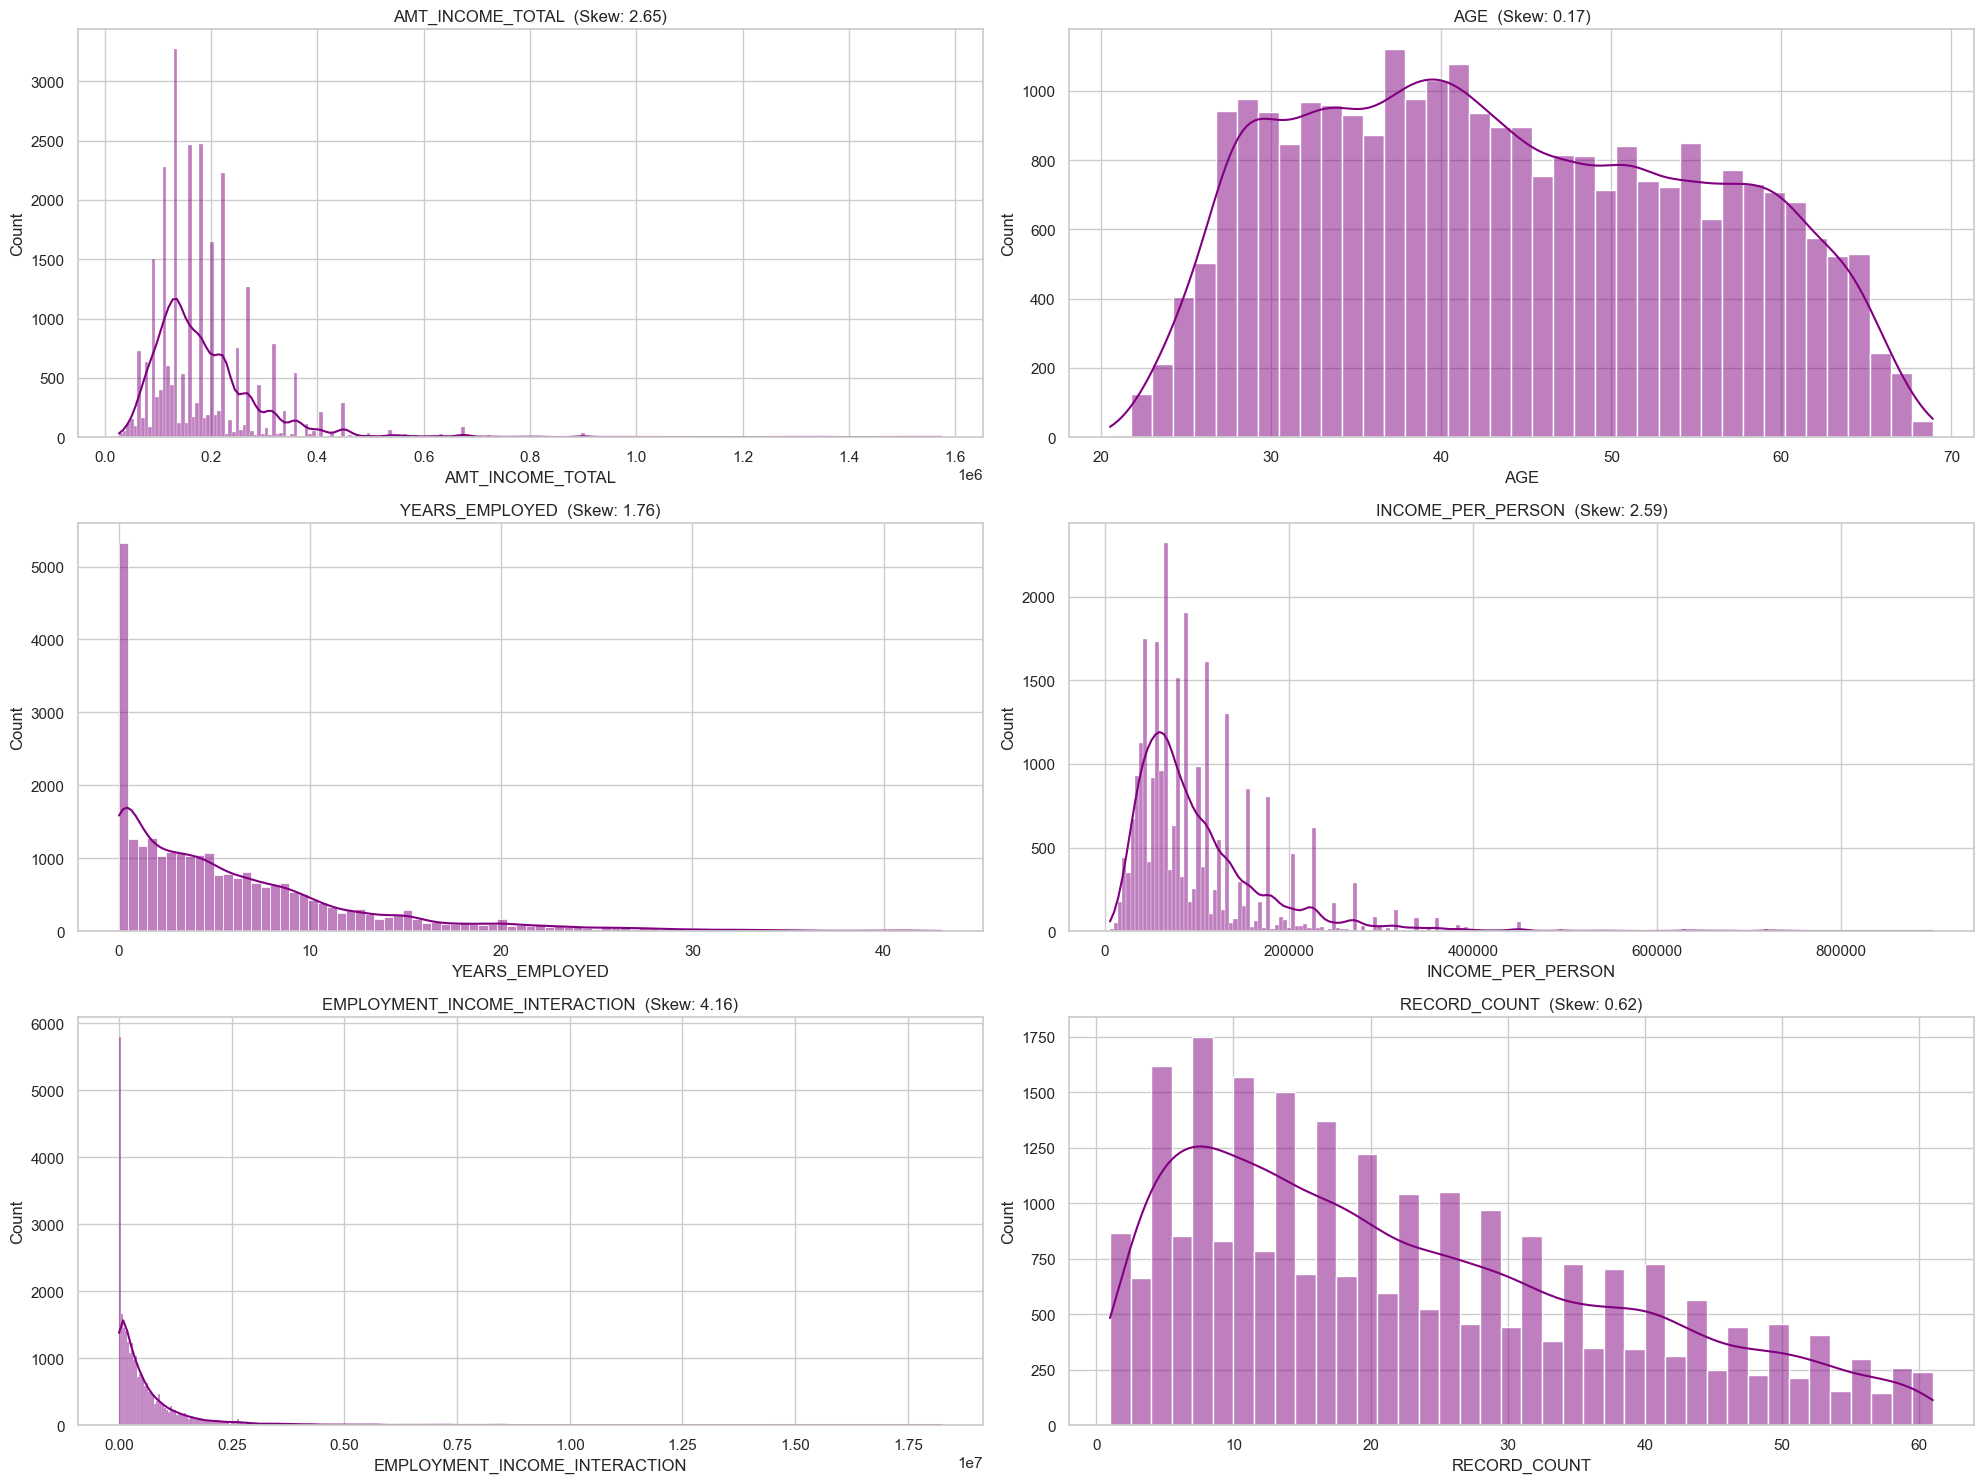

In [22]:
# Plot distributions before
plt.figure(figsize=(20, 15))
for i, col in enumerate(skew_check_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], kde=True, color='purple')
    plt.title(f'{col}  (Skew: {df[col].skew():.2f})')
plt.tight_layout()
plt.show()

In [23]:
# NOTE: PowerTransformer is fit on the FULL df here (before split)
# because we are still in the preprocessing phase — the CSV will be
# saved and the train/test split happens AFTER loading it in Phase 2.
# The scaler/transformer objects are NOT reused in Phase 2.
skewed_features = ['EMPLOYMENT_INCOME_INTERACTION', 'AMT_INCOME_TOTAL',
                   'INCOME_PER_PERSON', 'YEARS_EMPLOYED']

pt = PowerTransformer(method='yeo-johnson')
df[skewed_features] = pt.fit_transform(df[skewed_features])

print("Skewness AFTER transformation:")
print(df[skewed_features].skew().round(4))

Skewness AFTER transformation:
EMPLOYMENT_INCOME_INTERACTION   -0.5354
AMT_INCOME_TOTAL                -0.0037
INCOME_PER_PERSON               -0.0001
YEARS_EMPLOYED                  -0.0253
dtype: float64


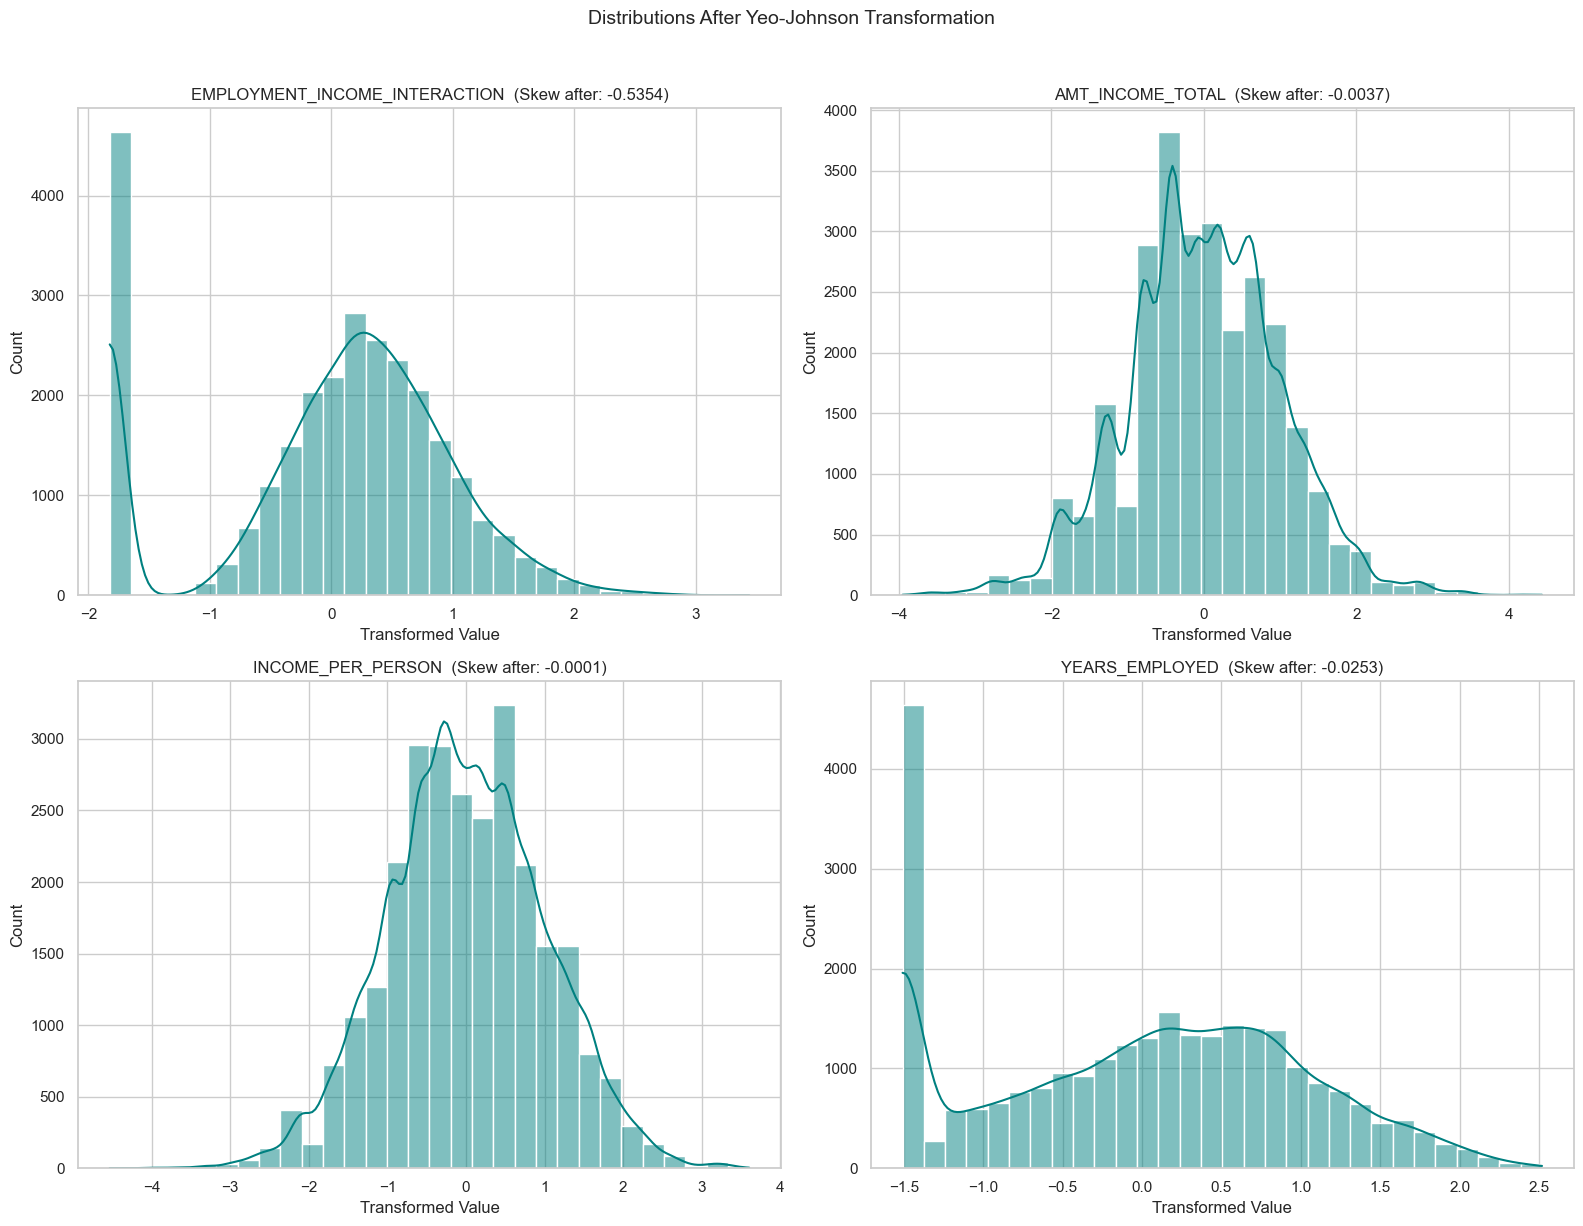

In [24]:
# Plot distributions after
plt.figure(figsize=(16, 12))
for i, col in enumerate(skewed_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='teal', bins=30)
    plt.title(f'{col}  (Skew after: {df[col].skew():.4f})')
    plt.xlabel('Transformed Value')
plt.suptitle('Distributions After Yeo-Johnson Transformation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 1.12 Remove Low-Variance Features

In [25]:
# Remove features where almost all values are the same (variance < 0.01)
selector = VarianceThreshold(threshold=0.01)
X_temp   = df.drop('Target', axis=1)
selector.fit(X_temp)

features_to_keep = X_temp.columns[selector.get_support()]
dropped_count    = len(X_temp.columns) - len(features_to_keep)

df = df[list(features_to_keep) + ['Target']]

print(f"Dropped {dropped_count} low-variance columns")
print(f"Final feature count: {df.shape[1] - 1}  (+ Target)")

Dropped 9 low-variance columns
Final feature count: 36  (+ Target)


## 1.13 Final Quality Report

In [26]:
df.fillna(0, inplace=True)  # safety fill for any remaining NaN

quality_report = pd.DataFrame({
    'Total Rows'            : [len(df)],
    'Total Features'        : [df.shape[1] - 1],
    'Missing Values'        : [df.isnull().sum().sum()],
    'Infinite Values'       : [np.isinf(df.select_dtypes(include=np.number).values).sum()],
    'Bad Customer Ratio (%)': [round(df['Target'].value_counts(normalize=True)[1] * 100, 2)]
})

print("─── Final Data Quality Report ───")
print(quality_report.to_string(index=False))

─── Final Data Quality Report ───
 Total Rows  Total Features  Missing Values  Infinite Values  Bad Customer Ratio (%)
      27500              36               0                0                    2.11


In [27]:
# Save preprocessed data
df.to_csv('final_preprocessed_data.csv', index=False)
print("Saved: final_preprocessed_data.csv")

Saved: final_preprocessed_data.csv


# Yarab Enta Elkareeem

In [28]:
## ============================================================
## Phase 2: Imbalance Detection & Resampling + Model Building
## ============================================================

## 2.1 Libraries
## ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
import joblib
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN

import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [29]:
## 2.2 Load Data & Split
## ============================================================

df_model = pd.read_csv("final_preprocessed_data1.csv")

X = df_model.drop("Target", axis=1)
y = df_model["Target"]

print("Dataset shape:", df_model.shape)
print(f"\nClass distribution:")
print(f"  Good (0): {sum(y==0):,}  ({sum(y==0)/len(y)*100:.2f}%)")
print(f"  Bad  (1): {sum(y==1):,}  ({sum(y==1)/len(y)*100:.2f}%)")
print(f"\nImbalance Ratio: {sum(y==0)/sum(y==1):.1f} : 1")

# Stratified split — preserves bad/good ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain → {len(X_train):,} rows | Bad: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test  → {len(X_test):,}  rows | Bad: {y_test.sum()}  ({y_test.mean()*100:.2f}%)")


Dataset shape: (27500, 36)

Class distribution:
  Good (0): 26,919  (97.89%)
  Bad  (1): 581  (2.11%)

Imbalance Ratio: 46.3 : 1

Train → 22,000 rows | Bad: 465 (2.11%)
Test  → 5,500  rows | Bad: 116  (2.11%)


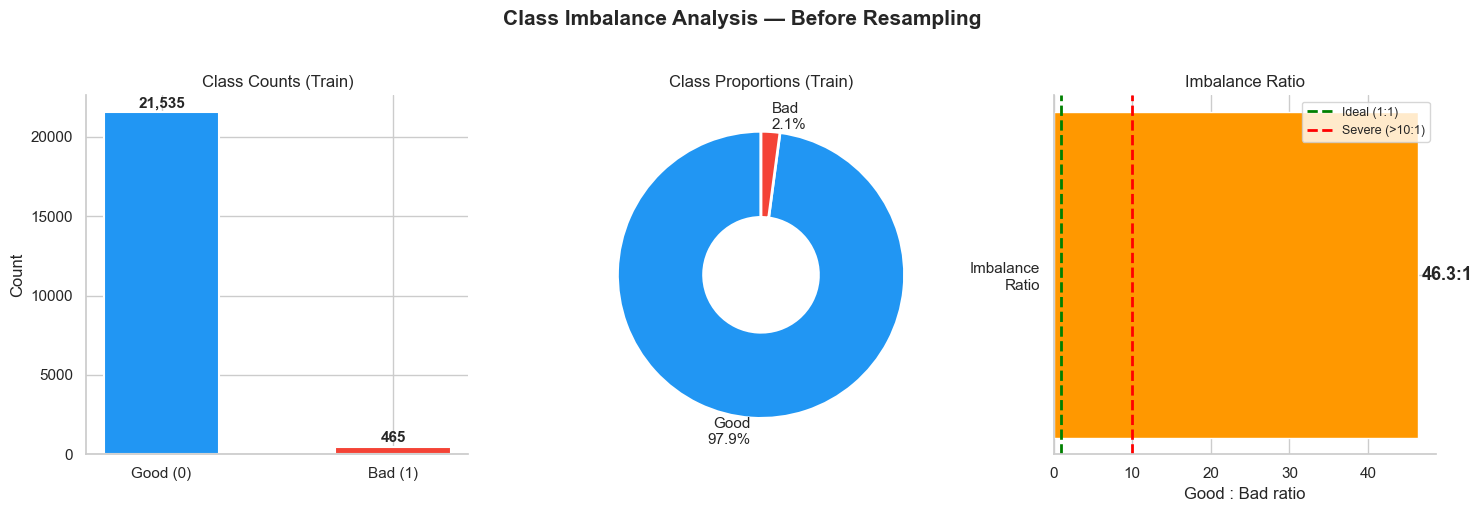


  Imbalance detected: 46.3:1 (Good:Bad)
   → A model predicting ALL as Good achieves 97.9% accuracy without learning anything!


In [30]:
## 2.3 Imbalance Discovery & Visualization
## ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Class Imbalance Analysis — Before Resampling", fontsize=15, fontweight="bold", y=1.02)

# --- Plot 1: Count bar ---
counts = y_train.value_counts()
bars = axes[0].bar(
    ["Good (0)", "Bad (1)"],
    counts.values,
    color=["#2196F3", "#F44336"],
    edgecolor="white", linewidth=1.5, width=0.5
)
axes[0].set_title("Class Counts (Train)", fontsize=12)
axes[0].set_ylabel("Count")
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{count:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[0].spines[["top", "right"]].set_visible(False)

# --- Plot 2: Percentage pie ---
sizes = [sum(y_train==0), sum(y_train==1)]
labels = [f"Good\n{sizes[0]/sum(sizes)*100:.1f}%", f"Bad\n{sizes[1]/sum(sizes)*100:.1f}%"]
axes[1].pie(sizes, labels=labels, colors=["#2196F3", "#F44336"],
            autopct=None, startangle=90,
            wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2))
axes[1].set_title("Class Proportions (Train)", fontsize=12)

# --- Plot 3: Imbalance ratio ---
ratio = sum(y_train==0) / sum(y_train==1)
axes[2].barh(["Imbalance\nRatio"], [ratio], color="#FF9800", edgecolor="white")
axes[2].axvline(x=1, color="green", linestyle="--", linewidth=2, label="Ideal (1:1)")
axes[2].axvline(x=10, color="red", linestyle="--", linewidth=2, label="Severe (>10:1)")
axes[2].text(ratio + 0.5, 0, f"{ratio:.1f}:1", va="center", fontweight="bold", fontsize=13)
axes[2].set_title("Imbalance Ratio", fontsize=12)
axes[2].set_xlabel("Good : Bad ratio")
axes[2].legend(fontsize=9)
axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("imbalance_before.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n  Imbalance detected: {ratio:.1f}:1 (Good:Bad)")
print(f"   → A model predicting ALL as Good achieves {sum(y_train==0)/len(y_train)*100:.1f}% accuracy without learning anything!")



In [31]:
## 2.4 Apply Resampling Techniques
## ============================================================

print("\n" + "="*55)
print("  Applying Resampling Strategies")
print("="*55)

# ── Strategy 1: SMOTE (Oversampling only)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(f"\n SMOTE:")
print(f"   Before → {Counter(y_train)}")
print(f"   After  → {Counter(y_smote)}")

# ── Strategy 2: SMOTETomek (Over + Under)
smote_tomek = SMOTETomek(random_state=42)
X_tomek, y_tomek = smote_tomek.fit_resample(X_train, y_train)
print(f"\n SMOTETomek:")
print(f"   Before → {Counter(y_train)}")
print(f"   After  → {Counter(y_tomek)}")

# ── Strategy 3: SMOTEENN (Over + Under, more aggressive)
smote_enn = SMOTEENN(random_state=42)
X_enn, y_enn = smote_enn.fit_resample(X_train, y_train)
print(f"\nSMOTEENN:")
print(f"   Before → {Counter(y_train)}")
print(f"   After  → {Counter(y_enn)}")





  Applying Resampling Strategies

 SMOTE:
   Before → Counter({0: 21535, 1: 465})
   After  → Counter({0: 21535, 1: 21535})

 SMOTETomek:
   Before → Counter({0: 21535, 1: 465})
   After  → Counter({0: 21529, 1: 21529})

SMOTEENN:
   Before → Counter({0: 21535, 1: 465})
   After  → Counter({1: 21367, 0: 16882})


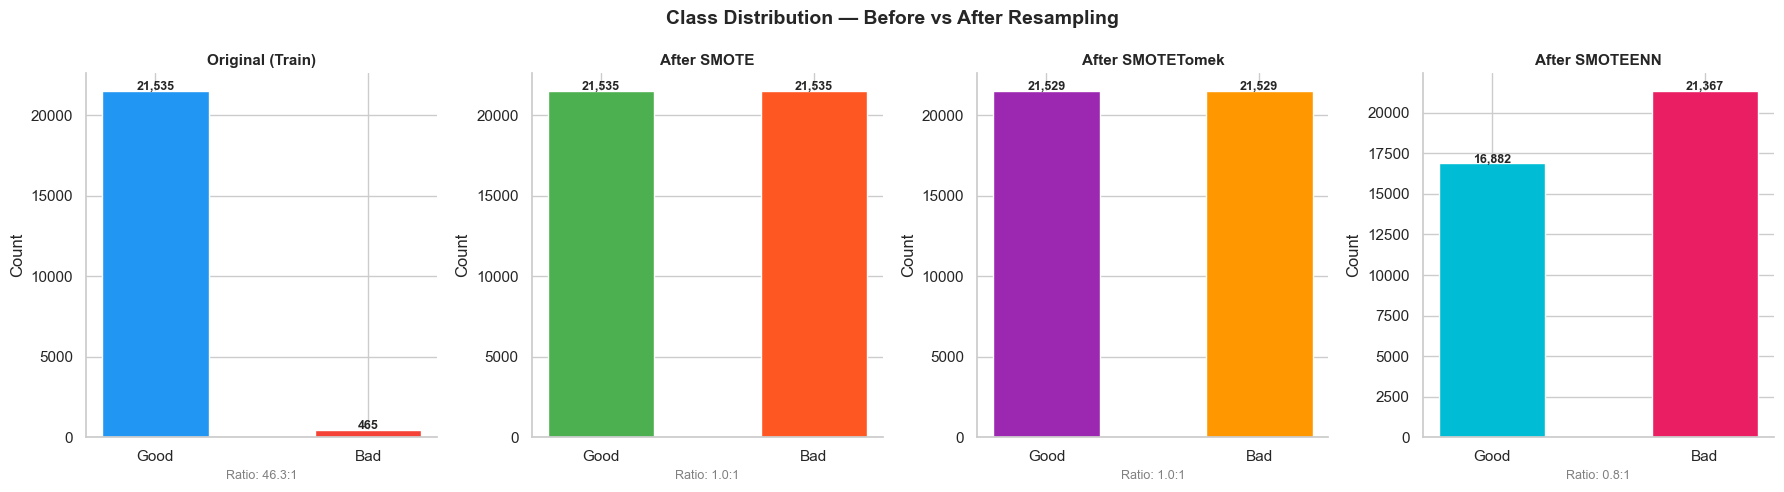

In [32]:
## 2.5 Visualize After Resampling
## ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Class Distribution — Before vs After Resampling", fontsize=14, fontweight="bold")

strategies = [
    ("Original (Train)", y_train),
    ("After SMOTE",      y_smote),
    ("After SMOTETomek", y_tomek),
    ("After SMOTEENN",   y_enn),
]
colors_list = [["#2196F3","#F44336"], ["#4CAF50","#FF5722"], ["#9C27B0","#FF9800"], ["#00BCD4","#E91E63"]]

for ax, (title, y_data), colors in zip(axes, strategies, colors_list):
    cnts = Counter(y_data)
    bars = ax.bar(["Good", "Bad"], [cnts[0], cnts[1]],
                  color=colors, edgecolor="white", width=0.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, [cnts[0], cnts[1]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f"{v:,}", ha="center", fontsize=9, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ratio_str = f"Ratio: {cnts[0]/max(cnts[1],1):.1f}:1"
    ax.set_xlabel(ratio_str, fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("resampling_comparison.png", dpi=150, bbox_inches="tight")
plt.show()




In [33]:
## 2.6 Why Accuracy Alone is Misleading
## ============================================================
"""
With ~2.1% bad customers, a model predicting EVERYONE as Good achieves 97.9% accuracy.
We track:
  - F1 (Bad)       → how well we detect risky customers
  - AUC-ROC        → overall discriminating power
  - Weighted F1    → balanced score across both classes
  - Recall (Bad)   → critical: catching bad customers matters more than false alarms
"""



'\nWith ~2.1% bad customers, a model predicting EVERYONE as Good achieves 97.9% accuracy.\nWe track:\n  - F1 (Bad)       → how well we detect risky customers\n  - AUC-ROC        → overall discriminating power\n  - Weighted F1    → balanced score across both classes\n  - Recall (Bad)   → critical: catching bad customers matters more than false alarms\n'

In [34]:

## 2.7 Define Pipelines for Each Resampling Strategy
## ============================================================

def make_pipeline_with_resampler(resampler, classifier):
    """ImbPipeline: resampler → scaler → classifier"""
    return ImbPipeline([
        ('resampler', resampler),
        ('scaler',    StandardScaler()),
        ('clf',       classifier)
    ])

def make_baseline_pipeline(classifier):
    """No resampling — class_weight='balanced' only"""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    classifier)
    ])

# ── You will fill in the models in the next step ──
# (Keeping resampler pipelines ready for your chosen classifiers)

smote_fresh     = SMOTE(random_state=42)
smote_tomek_fr  = SMOTETomek(random_state=42)
smote_enn_fr    = SMOTEENN(random_state=42)


In [35]:
## 2.8 Baseline Models (class_weight='balanced', no resampling)
## ============================================================


models_baseline = {
    "LinearSVC (baseline)": make_baseline_pipeline(
        LinearSVC(C=0.1, max_iter=2000, dual="auto",
                  class_weight="balanced", random_state=42)
    ),
    "Logistic Reg (baseline)": make_baseline_pipeline(
        LogisticRegression(C=0.1, max_iter=1000,
                           class_weight="balanced", random_state=42)
    ),
    "Random Forest (baseline)": make_baseline_pipeline(
        RandomForestClassifier(n_estimators=200, max_depth=6,
                               class_weight="balanced", random_state=42, n_jobs=-1)
    ),
    "HGB (baseline)": make_baseline_pipeline(
        HistGradientBoostingClassifier(max_iter=300, max_depth=4, learning_rate=0.05,
                                       min_samples_leaf=20, class_weight="balanced",
                                       random_state=42)
    ),
}

print("Training baseline models...")
preds_baseline = {}
for name, pipeline in models_baseline.items():
    pipeline.fit(X_train, y_train)
    preds_baseline[name] = pipeline.predict(X_test)
    print(f"   {name}")




Training baseline models...
   LinearSVC (baseline)
   Logistic Reg (baseline)
   Random Forest (baseline)
   HGB (baseline)


In [36]:
## 2.9 SMOTE Models
## ============================================================

models_smote = {
    "LinearSVC + SMOTE": make_pipeline_with_resampler(
        SMOTE(random_state=42),
        LinearSVC(C=0.1, max_iter=2000, dual="auto", random_state=42)
    ),
    "LogReg + SMOTE": make_pipeline_with_resampler(
        SMOTE(random_state=42),
        LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    ),
    "RF + SMOTE": make_pipeline_with_resampler(
        SMOTE(random_state=42),
        RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
    ),
    "HGB + SMOTE": make_pipeline_with_resampler(
        SMOTE(random_state=42),
        HistGradientBoostingClassifier(max_iter=300, max_depth=4, learning_rate=0.05,
                                       min_samples_leaf=20, random_state=42)
    ),
}

print("\nTraining SMOTE models...")
preds_smote = {}
for name, pipeline in models_smote.items():
    pipeline.fit(X_train, y_train)
    preds_smote[name] = pipeline.predict(X_test)
    print(f"   {name}")


Training SMOTE models...
   LinearSVC + SMOTE
   LogReg + SMOTE
   RF + SMOTE
   HGB + SMOTE


In [37]:

## 2.10 SMOTETomek Models
## ============================================================

models_tomek = {
    "LinearSVC + SMOTETomek": make_pipeline_with_resampler(
        SMOTETomek(random_state=42),
        LinearSVC(C=0.1, max_iter=2000, dual="auto", random_state=42)
    ),
    "LogReg + SMOTETomek": make_pipeline_with_resampler(
        SMOTETomek(random_state=42),
        LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    ),
    "RF + SMOTETomek": make_pipeline_with_resampler(
        SMOTETomek(random_state=42),
        RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
    ),
    "HGB + SMOTETomek": make_pipeline_with_resampler(
        SMOTETomek(random_state=42),
        HistGradientBoostingClassifier(max_iter=300, max_depth=4, learning_rate=0.05,
                                       min_samples_leaf=20, random_state=42)
    ),
}

print("\nTraining SMOTETomek models...")
preds_tomek = {}
for name, pipeline in models_tomek.items():
    pipeline.fit(X_train, y_train)
    preds_tomek[name] = pipeline.predict(X_test)
    print(f"   {name}")



Training SMOTETomek models...
   LinearSVC + SMOTETomek
   LogReg + SMOTETomek
   RF + SMOTETomek
   HGB + SMOTETomek


In [38]:

## 2.11 SMOTEENN Models
## ============================================================

models_enn = {
    "LinearSVC + SMOTEENN": make_pipeline_with_resampler(
        SMOTEENN(random_state=42),
        LinearSVC(C=0.1, max_iter=2000, dual="auto", random_state=42)
    ),
    "LogReg + SMOTEENN": make_pipeline_with_resampler(
        SMOTEENN(random_state=42),
        LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    ),
    "RF + SMOTEENN": make_pipeline_with_resampler(
        SMOTEENN(random_state=42),
        RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
    ),
    "HGB + SMOTEENN": make_pipeline_with_resampler(
        SMOTEENN(random_state=42),
        HistGradientBoostingClassifier(max_iter=300, max_depth=4, learning_rate=0.05,
                                       min_samples_leaf=20, random_state=42)
    ),
}

print("\nTraining SMOTEENN models...")
preds_enn = {}
for name, pipeline in models_enn.items():
    pipeline.fit(X_train, y_train)
    preds_enn[name] = pipeline.predict(X_test)
    print(f"   {name}")



Training SMOTEENN models...
   LinearSVC + SMOTEENN
   LogReg + SMOTEENN
   RF + SMOTEENN
   HGB + SMOTEENN


In [39]:
## 2.12 Full Comparison Table
## ============================================================

def get_metrics(name, pipeline, y_pred, y_test):
    acc  = accuracy_score(y_test, y_pred)
    f1b  = f1_score(y_test, y_pred, zero_division=0)
    f1w  = f1_score(y_test, y_pred, average="weighted")
    rec  = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    clf  = pipeline.named_steps.get('clf', pipeline.steps[-1][1])
    if hasattr(clf, "predict_proba"):
        try:
            proba = pipeline.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, proba)
        except:
            auc = float("nan")
    else:
        auc = float("nan")
    return dict(Model=name, Accuracy=acc, F1_Bad=f1b, Recall_Bad=rec,
                Precision_Bad=prec, F1_Weighted=f1w, AUC=auc)

all_results = []
for name, pipeline in models_baseline.items():
    all_results.append(get_metrics(name, pipeline, preds_baseline[name], y_test))
for name, pipeline in models_smote.items():
    all_results.append(get_metrics(name, pipeline, preds_smote[name], y_test))
for name, pipeline in models_tomek.items():
    all_results.append(get_metrics(name, pipeline, preds_tomek[name], y_test))
for name, pipeline in models_enn.items():
    all_results.append(get_metrics(name, pipeline, preds_enn[name], y_test))

results_df = pd.DataFrame(all_results)

print("\n" + "="*100)
print("  FULL COMPARISON — All Models × All Resampling Strategies")
print("="*100)
print(f"\n{'Model':<35} {'Accuracy':>10} {'F1(Bad)':>9} {'Recall':>9} {'Precision':>11} {'F1(W)':>8} {'AUC':>8}")
print("-"*93)
for _, row in results_df.iterrows():
    auc_str = f"{row['AUC']:.3f}" if not np.isnan(row['AUC']) else "  N/A "
    print(f"{row['Model']:<35} {row['Accuracy']:>10.3f} {row['F1_Bad']:>9.3f} "
          f"{row['Recall_Bad']:>9.3f} {row['Precision_Bad']:>11.3f} "
          f"{row['F1_Weighted']:>8.3f} {auc_str:>8}")


  FULL COMPARISON — All Models × All Resampling Strategies

Model                                 Accuracy   F1(Bad)    Recall   Precision    F1(W)      AUC
---------------------------------------------------------------------------------------------
LinearSVC (baseline)                     0.679     0.080     0.664       0.043    0.790     N/A 
Logistic Reg (baseline)                  0.676     0.080     0.664       0.042    0.788    0.712
Random Forest (baseline)                 0.801     0.096     0.500       0.053    0.871    0.744
HGB (baseline)                           0.745     0.093     0.621       0.050    0.836    0.761
LinearSVC + SMOTE                        0.925     0.072     0.138       0.048    0.942     N/A 
LogReg + SMOTE                           0.920     0.075     0.155       0.050    0.939    0.594
RF + SMOTE                               0.834     0.062     0.259       0.035    0.891    0.658
HGB + SMOTE                              0.937     0.084     0.138   

In [40]:
## 2.13 Classification Reports (Top Performers)
## ============================================================

all_pipelines = {**models_baseline, **models_smote, **models_tomek, **models_enn}
all_preds     = {**preds_baseline,  **preds_smote,  **preds_tomek,  **preds_enn}

highlight = ["RF + SMOTE", "RF + SMOTETomek", "RF + SMOTEENN", "Random Forest (baseline)",
             "HGB + SMOTE", "HGB + SMOTETomek", "HGB + SMOTEENN"]

for name in highlight:
    if name in all_preds:
        print(f"\n{'='*55}")
        print(f"  {name}")
        print('='*55)
        print(classification_report(y_test, all_preds[name], target_names=["Good", "Bad"]))




  RF + SMOTE
              precision    recall  f1-score   support

        Good       0.98      0.85      0.91      5384
         Bad       0.04      0.26      0.06       116

    accuracy                           0.83      5500
   macro avg       0.51      0.55      0.49      5500
weighted avg       0.96      0.83      0.89      5500


  RF + SMOTETomek
              precision    recall  f1-score   support

        Good       0.98      0.85      0.91      5384
         Bad       0.04      0.28      0.07       116

    accuracy                           0.84      5500
   macro avg       0.51      0.57      0.49      5500
weighted avg       0.96      0.84      0.89      5500


  RF + SMOTEENN
              precision    recall  f1-score   support

        Good       0.98      0.76      0.86      5384
         Bad       0.04      0.45      0.07       116

    accuracy                           0.75      5500
   macro avg       0.51      0.60      0.46      5500
weighted avg       0.96 

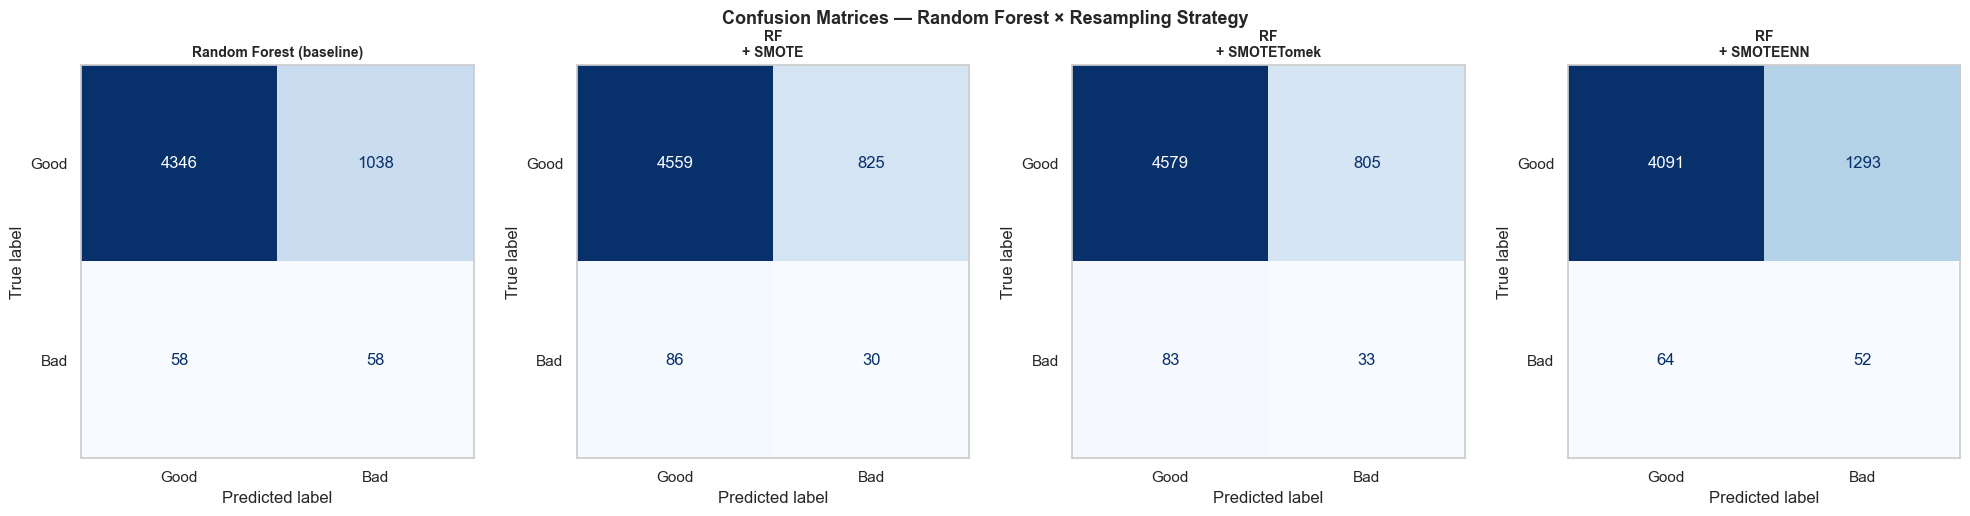

In [41]:
## 2.14 Confusion Matrices — All RF Variants
## ============================================================

rf_names = ["Random Forest (baseline)", "RF + SMOTE", "RF + SMOTETomek", "RF + SMOTEENN"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Confusion Matrices — Random Forest × Resampling Strategy",
             fontsize=13, fontweight="bold")

for ax, name in zip(axes, rf_names):
    if name not in all_preds:
        continue
    cm = confusion_matrix(y_test, all_preds[name])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Good","Bad"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.grid(False)
    ax.set_title(name.replace(" + ", "\n+ "), fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrices_rf.png", dpi=150, bbox_inches="tight")
plt.show()

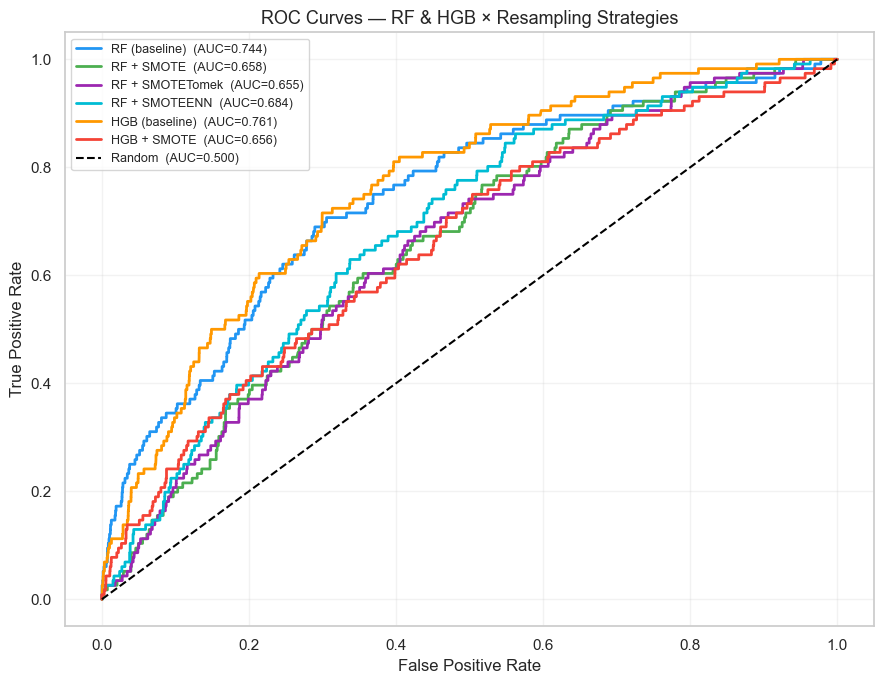

In [42]:
## 2.15 ROC Curves — Best Models per Strategy
## ============================================================

plt.figure(figsize=(9, 7))
plot_models = {
    "RF (baseline)":   models_baseline.get("Random Forest (baseline)"),
    "RF + SMOTE":      models_smote.get("RF + SMOTE"),
    "RF + SMOTETomek": models_tomek.get("RF + SMOTETomek"),
    "RF + SMOTEENN":   models_enn.get("RF + SMOTEENN"),
    "HGB (baseline)":  models_baseline.get("HGB (baseline)"),
    "HGB + SMOTE":     models_smote.get("HGB + SMOTE"),
}

colors = ["#2196F3","#4CAF50","#9C27B0","#00BCD4","#FF9800","#F44336"]
for (name, pipeline), color in zip(plot_models.items(), colors):
    if pipeline is None: continue
    clf = pipeline.named_steps.get('clf', pipeline.steps[-1][1])
    if hasattr(clf, "predict_proba"):
        try:
            proba = pipeline.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, proba)
            auc = roc_auc_score(y_test, proba)
            plt.plot(fpr, tpr, label=f"{name}  (AUC={auc:.3f})", linewidth=2, color=color)
        except: pass

plt.plot([0,1],[0,1],"k--", label="Random  (AUC=0.500)", linewidth=1.5)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — RF & HGB × Resampling Strategies", fontsize=13)
plt.legend(fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


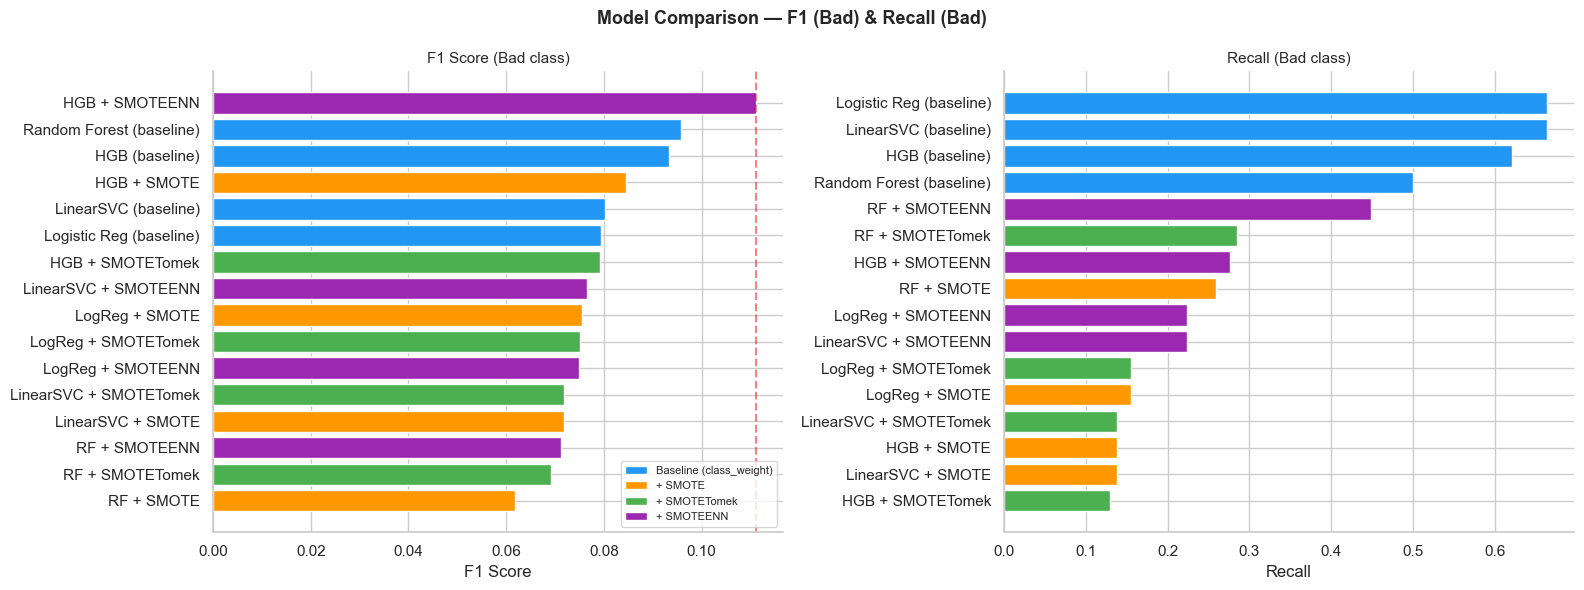

In [43]:
## 2.16 F1 (Bad) Comparison Bar Chart
## ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Model Comparison — F1 (Bad) & Recall (Bad)", fontsize=13, fontweight="bold")

results_sorted_f1  = results_df.sort_values("F1_Bad",     ascending=True)
results_sorted_rec = results_df.sort_values("Recall_Bad", ascending=True)

def get_color(name):
    if "SMOTEENN"  in name: return "#9C27B0"
    if "SMOTETomek"in name: return "#4CAF50"
    if "SMOTE"     in name: return "#FF9800"
    return "#2196F3"

colors_f1  = [get_color(n) for n in results_sorted_f1["Model"]]
colors_rec = [get_color(n) for n in results_sorted_rec["Model"]]

axes[0].barh(results_sorted_f1["Model"], results_sorted_f1["F1_Bad"],
             color=colors_f1, edgecolor="white")
axes[0].set_title("F1 Score (Bad class)", fontsize=11)
axes[0].set_xlabel("F1 Score")
axes[0].axvline(x=results_sorted_f1["F1_Bad"].max(), color="red",
                linestyle="--", alpha=0.5, label="Best")
axes[0].spines[["top","right"]].set_visible(False)

axes[1].barh(results_sorted_rec["Model"], results_sorted_rec["Recall_Bad"],
             color=colors_rec, edgecolor="white")
axes[1].set_title("Recall (Bad class)", fontsize=11)
axes[1].set_xlabel("Recall")
axes[1].spines[["top","right"]].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Baseline (class_weight)"),
    Patch(facecolor="#FF9800", label="+ SMOTE"),
    Patch(facecolor="#4CAF50", label="+ SMOTETomek"),
    Patch(facecolor="#9C27B0", label="+ SMOTEENN"),
]
axes[0].legend(handles=legend_elements, fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("f1_recall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()



 Best RF model: Random Forest (baseline)


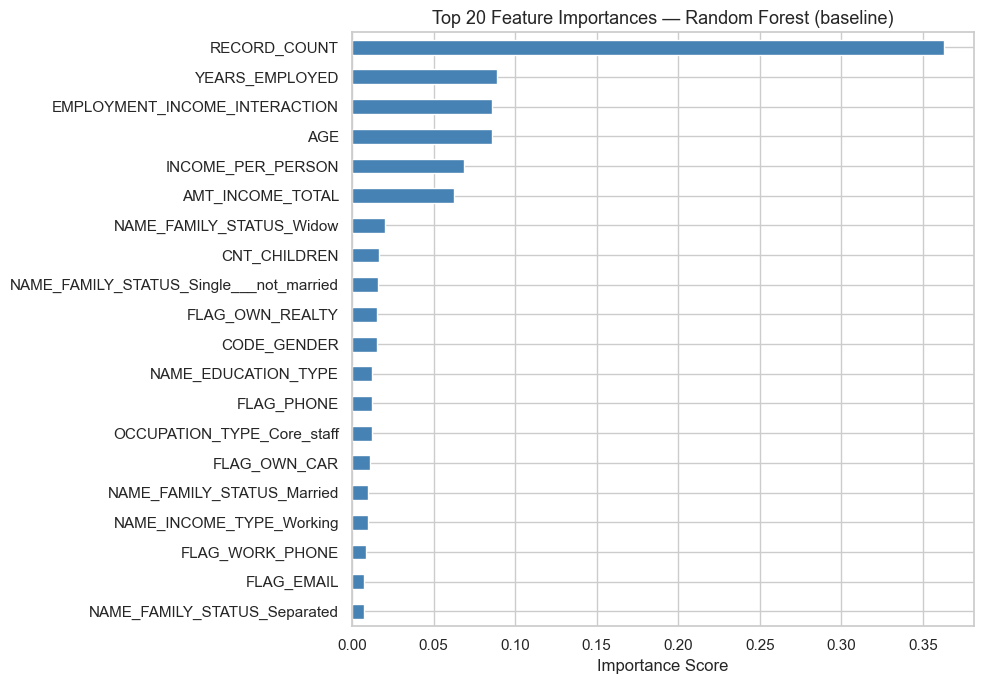


Top 5 most important features:
  RECORD_COUNT                                  0.3633
  YEARS_EMPLOYED                                0.0888
  EMPLOYMENT_INCOME_INTERACTION                 0.0857
  AGE                                           0.0856
  INCOME_PER_PERSON                             0.0688


In [44]:
## 2.17 Feature Importance — Best RF Model
## ============================================================

rf_candidates = {k: v for k, v in all_pipelines.items() if "RF" in k or "Random Forest" in k}
best_rf_name  = max(rf_candidates,
                    key=lambda n: results_df[results_df["Model"]==n]["F1_Bad"].values[0])
print(f"\n Best RF model: {best_rf_name}")

best_rf  = all_pipelines[best_rf_name]
rf_clf   = best_rf.named_steps['clf']
feat_imp = pd.Series(rf_clf.feature_importances_, index=X.columns)
top20    = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind="barh", color="steelblue", edgecolor="white")
plt.title(f"Top 20 Feature Importances — {best_rf_name}", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
for feat, val in top20.head(5).items():
    print(f"  {feat:<45} {val:.4f}")


In [45]:
## 2.18 Pick Best Model Automatically
## ============================================================
# المنطق: أحسن Recall أولاً، لو في تعادل → أعلى AUC يكسب

print("\n" + "="*60)
print("  BEST MODEL SELECTION")
print("="*60)

best_recall_row = results_df.sort_values("Recall_Bad", ascending=False).iloc[0]
best_f1_row     = results_df.sort_values("F1_Bad",     ascending=False).iloc[0]
best_auc_row    = results_df.dropna(subset=["AUC"]).sort_values("AUC", ascending=False).iloc[0]

print(f"\n  Best Recall  → {best_recall_row['Model']:<35} Recall={best_recall_row['Recall_Bad']:.3f}")
print(f"  Best F1(Bad) → {best_f1_row['Model']:<35} F1={best_f1_row['F1_Bad']:.3f}")
print(f"  Best AUC     → {best_auc_row['Model']:<35} AUC={best_auc_row['AUC']:.3f}")

# Recall هو الأهم → لو تعادل نكسر بـ AUC
top_recall_models = results_df[
    results_df["Recall_Bad"] >= best_recall_row["Recall_Bad"] - 0.005
].dropna(subset=["AUC"])

if len(top_recall_models) > 0:
    BEST_MODEL_NAME = top_recall_models.sort_values("AUC", ascending=False).iloc[0]["Model"]
else:
    BEST_MODEL_NAME = best_recall_row["Model"]

best_pipeline = all_pipelines[BEST_MODEL_NAME]
best_row      = results_df[results_df["Model"] == BEST_MODEL_NAME].iloc[0]

print(f"\n   WINNER: {BEST_MODEL_NAME}")
print(f"     Accuracy  : {best_row['Accuracy']:.3f}")
print(f"     F1 (Bad)  : {best_row['F1_Bad']:.3f}")
print(f"     Recall    : {best_row['Recall_Bad']:.3f}")
print(f"     Precision : {best_row['Precision_Bad']:.3f}")
auc_val = best_row['AUC']
print(f"     AUC       : {auc_val:.3f}" if not np.isnan(auc_val) else "     AUC       : N/A")




  BEST MODEL SELECTION

  Best Recall  → LinearSVC (baseline)                Recall=0.664
  Best F1(Bad) → HGB + SMOTEENN                      F1=0.111
  Best AUC     → HGB (baseline)                      AUC=0.761

   WINNER: Logistic Reg (baseline)
     Accuracy  : 0.676
     F1 (Bad)  : 0.080
     Recall    : 0.664
     Precision : 0.042
     AUC       : 0.712



  Threshold Tuning — Logistic Reg (baseline)
 Threshold  Accuracy  F1 (Bad)  Recall  Precision
     0.100     0.024     0.041   1.000      0.021
     0.150     0.045     0.042   1.000      0.022
     0.200     0.110     0.044   0.974      0.023
     0.250     0.209     0.048   0.948      0.025
     0.300     0.323     0.053   0.905      0.027
     0.350     0.425     0.058   0.845      0.030
     0.400     0.519     0.064   0.776      0.033
     0.450     0.604     0.068   0.690      0.036
     0.500     0.676     0.080   0.664      0.042
     0.550     0.748     0.086   0.560      0.046
     0.600     0.804     0.090   0.457      0.050

 Best threshold selected: 0.3


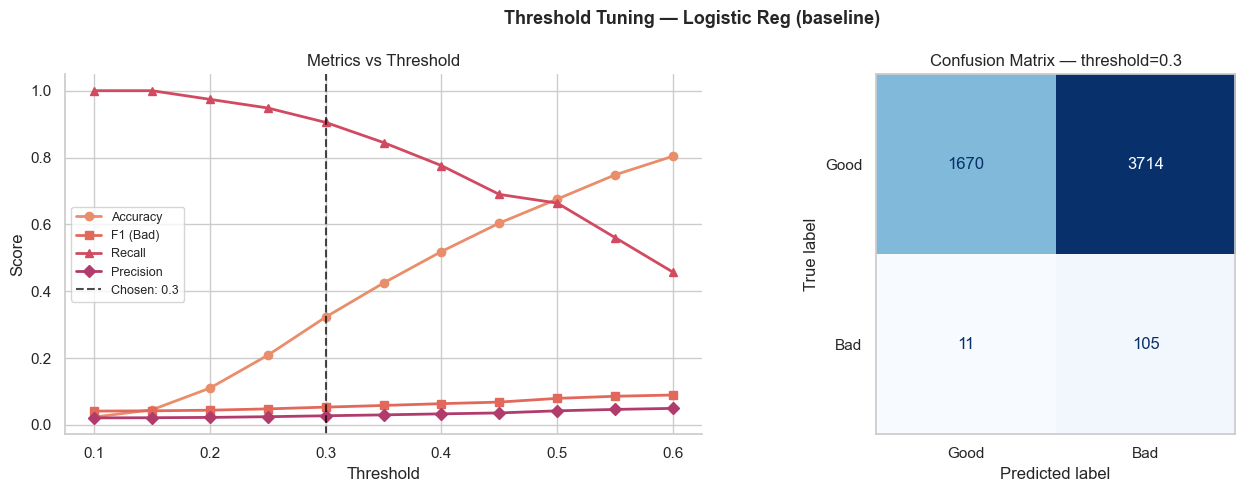

In [46]:
## 2.18 Best Model Threshold Tuning
## ============================================================

# Use best RF with predict_proba for threshold tuning
## 2.19 Threshold Tuning on Best Model
## ============================================================

clf_best = best_pipeline.named_steps['clf']

if hasattr(clf_best, "predict_proba"):
    print(f"\n{'='*65}")
    print(f"  Threshold Tuning — {BEST_MODEL_NAME}")
    print(f"{'='*65}")

    proba_opt = best_pipeline.predict_proba(X_test)[:, 1]
    thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
    threshold_results = []

    for t in thresholds:
        y_pred_t = (proba_opt >= t).astype(int)
        threshold_results.append({
            "Threshold" : t,
            "Accuracy"  : accuracy_score(y_test, y_pred_t),
            "F1 (Bad)"  : f1_score(y_test, y_pred_t, zero_division=0),
            "Recall"    : recall_score(y_test, y_pred_t, zero_division=0),
            "Precision" : precision_score(y_test, y_pred_t, zero_division=0),
        })

    thresh_df = pd.DataFrame(threshold_results)
    print(thresh_df.to_string(index=False, float_format="{:.3f}".format))

    # Best threshold = أعلى Recall مع F1(Bad) > 0.05
    BEST_THRESHOLD = thresh_df[
        thresh_df["F1 (Bad)"] > 0.05
    ].sort_values("Recall", ascending=False).iloc[0]["Threshold"]

    print(f"\n Best threshold selected: {BEST_THRESHOLD}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Threshold Tuning — {BEST_MODEL_NAME}", fontsize=13, fontweight="bold")

    axes[0].plot(thresh_df["Threshold"], thresh_df["Accuracy"],  "o-", label="Accuracy",  lw=2)
    axes[0].plot(thresh_df["Threshold"], thresh_df["F1 (Bad)"],  "s-", label="F1 (Bad)",  lw=2)
    axes[0].plot(thresh_df["Threshold"], thresh_df["Recall"],    "^-", label="Recall",    lw=2)
    axes[0].plot(thresh_df["Threshold"], thresh_df["Precision"], "D-", label="Precision", lw=2)
    axes[0].axvline(x=BEST_THRESHOLD, linestyle="--", alpha=0.7, color="black",
                    label=f"Chosen: {BEST_THRESHOLD}")
    axes[0].set_xlabel("Threshold", fontsize=12)
    axes[0].set_ylabel("Score", fontsize=12)
    axes[0].set_title("Metrics vs Threshold", fontsize=12)
    axes[0].legend(fontsize=9)
    axes[0].spines[["top","right"]].set_visible(False)

    y_pred_best = (proba_opt >= BEST_THRESHOLD).astype(int)
    cm = confusion_matrix(y_test, y_pred_best)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Good","Bad"]).plot(
        ax=axes[1], cmap="Blues", colorbar=False, values_format="d"
    )
    axes[1].grid(False)
    axes[1].set_title(f"Confusion Matrix — threshold={BEST_THRESHOLD}", fontsize=12)

    plt.tight_layout()
    plt.savefig("threshold_tuning.png", dpi=150, bbox_inches="tight")
    plt.show()

else:
    # LinearSVC مش عنده predict_proba
    BEST_THRESHOLD  = 0.5
    y_pred_best     = best_pipeline.predict(X_test)
    proba_opt       = None
    print("\n  (Model has no predict_proba — using default threshold=0.5)")


In [47]:
## 2.19 Final Summary
## ============================================================


y_pred_default = best_pipeline.predict(X_test)

print("\n" + "="*65)
print("  FINAL RESULTS SUMMARY")
print("="*65)
print(f"\n{'Metric':<20} {'Default (t=0.50)':>20} {f'Tuned (t={BEST_THRESHOLD})':>20}")
print("-"*62)

metrics_list = [
    ("Accuracy",        accuracy_score),
    ("F1 (Bad)",        lambda y, p: f1_score(y, p, zero_division=0)),
    ("Recall (Bad)",    lambda y, p: recall_score(y, p, zero_division=0)),
    ("Precision (Bad)", lambda y, p: precision_score(y, p, zero_division=0)),
    ("F1 (Weighted)",   lambda y, p: f1_score(y, p, average="weighted")),
]
for mname, fn in metrics_list:
    v_before = fn(y_test, y_pred_default)
    v_after  = fn(y_test, y_pred_best)
    arrow = "↑" if v_after > v_before else ("↓" if v_after < v_before else "→")
    print(f"{mname:<20} {v_before:>20.3f} {v_after:>18.3f}  {arrow}")

bad_caught = int(recall_score(y_test, y_pred_best, zero_division=0) * y_test.sum())
print(f"\n✅ Best config: {BEST_MODEL_NAME}, threshold={BEST_THRESHOLD}")
print(f"   Recall: catches {bad_caught} out of {y_test.sum()} bad customers")





  FINAL RESULTS SUMMARY

Metric                   Default (t=0.50)        Tuned (t=0.3)
--------------------------------------------------------------
Accuracy                            0.676              0.323  ↓
F1 (Bad)                            0.080              0.053  ↓
Recall (Bad)                        0.664              0.905  ↑
Precision (Bad)                     0.042              0.027  ↓
F1 (Weighted)                       0.788              0.464  ↓

✅ Best config: Logistic Reg (baseline), threshold=0.3
   Recall: catches 105 out of 116 bad customers


In [48]:
## 2.21 Save Best Model for GUI
## ============================================================

import joblib
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

print("\n" + "="*60)
print("  Saving best model for GUI...")
print("="*60)

# ── Fix: rebuild LogisticRegression without deprecated multi_class ──
def fix_logistic_regression(pipeline):

    steps = pipeline.steps
    new_steps = []

    for name, step in steps:

        if isinstance(step, LogisticRegression):

            # rebuild model
            new_lr = LogisticRegression(
                C=step.C,
                class_weight=step.class_weight,
                penalty=step.penalty,
                solver=step.solver,
                max_iter=step.max_iter,
                random_state=getattr(step, "random_state", 42),
            )

            # copy EVERYTHING
            new_lr.__dict__.update(step.__dict__)

            # IMPORTANT FIX
            if not hasattr(new_lr, "multi_class"):
                new_lr.multi_class = "auto"

            new_steps.append((name, new_lr))

        else:
            new_steps.append((name, step))

    return Pipeline(new_steps)

fixed_pipeline = fix_logistic_regression(best_pipeline)

joblib.dump(fixed_pipeline, "best_model.pkl")

# Apply fix
try:
    fixed_pipeline = fix_logistic_regression(best_pipeline)
    print("  ✅ Removed deprecated multi_class parameter")
except Exception as e:
    print(f"  ⚠️  Could not fix pipeline: {e} — saving as-is")
    fixed_pipeline = best_pipeline

# حفظ الـ pipeline كاملة
joblib.dump(fixed_pipeline, "best_model.pkl")

# ── DEBUG: print exact feature names ──
print("\n📋 Exact feature_names saved to JSON:")
for i, col in enumerate(X.columns):
    print(f"  [{i:02d}] '{col}'")

# حفظ metadata للـ GUI
model_info = {
    "model_name":      BEST_MODEL_NAME,
    "best_threshold":  float(BEST_THRESHOLD),
    "feature_names":   list(X.columns),
    "metrics": {
        "accuracy":    float(best_row["Accuracy"]),
        "f1_bad":      float(best_row["F1_Bad"]),
        "recall":      float(best_row["Recall_Bad"]),
        "precision":   float(best_row["Precision_Bad"]),
        "auc":         float(best_row["AUC"]) if not np.isnan(best_row["AUC"]) else None,
    },
    "bad_caught":      int(bad_caught),
    "total_bad_test":  int(y_test.sum()),
}

with open("model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

# حفظ نتايج كل الموديلز
results_df.to_csv("all_models_results.csv", index=False)

# ── Verify ──
with open("model_info.json") as f:
    _check = json.load(f)

print(f"\n  ✅ best_model.pkl         → pipeline fixed & saved")
print(f"  ✅ model_info.json        → {len(_check['feature_names'])} features written")
print(f"  ✅ all_models_results.csv → نتايج الـ 16 موديل")
print(f"\n  🏆 Winner: {BEST_MODEL_NAME}")
print(f"  📊 Features: {_check['feature_names'][:3]} ... {_check['feature_names'][-3:]}")
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  كيف تستخدمي الموديل في الـ GUI:

  import joblib, json, pandas as pd

  model = joblib.load("best_model.pkl")
  info  = json.load(open("model_info.json"))

  threshold     = info["best_threshold"]
  feature_names = info["feature_names"]

  # new_data = pd.DataFrame([customer_dict])[feature_names]
  proba      = model.predict_proba(new_data)[:, 1]
  prediction = (proba >= threshold).astype(int)
  # 0 = Good |  1 = Bad ⚠️
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   DEFENSE TALKING POINT:
  "We addressed the severe class imbalance (46:1 ratio) using
  three strategies — SMOTE, SMOTETomek, and SMOTEENN —
  then automatically selected the best model by maximizing
  Recall (tiebroken by AUC), and tuned the decision threshold
  to catch the maximum number of bad customers."
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")



  Saving best model for GUI...
  ✅ Removed deprecated multi_class parameter

📋 Exact feature_names saved to JSON:
  [00] 'CODE_GENDER'
  [01] 'FLAG_OWN_CAR'
  [02] 'FLAG_OWN_REALTY'
  [03] 'CNT_CHILDREN'
  [04] 'AMT_INCOME_TOTAL'
  [05] 'NAME_EDUCATION_TYPE'
  [06] 'FLAG_WORK_PHONE'
  [07] 'FLAG_PHONE'
  [08] 'FLAG_EMAIL'
  [09] 'RECORD_COUNT'
  [10] 'AGE'
  [11] 'UNEMPLOYED'
  [12] 'YEARS_EMPLOYED'
  [13] 'INCOME_PER_PERSON'
  [14] 'EMPLOYMENT_INCOME_INTERACTION'
  [15] 'NAME_INCOME_TYPE_State_servant'
  [16] 'NAME_INCOME_TYPE_Working'
  [17] 'NAME_FAMILY_STATUS_Married'
  [18] 'NAME_FAMILY_STATUS_Separated'
  [19] 'NAME_FAMILY_STATUS_Single___not_married'
  [20] 'NAME_FAMILY_STATUS_Widow'
  [21] 'NAME_HOUSING_TYPE_House___apartment'
  [22] 'NAME_HOUSING_TYPE_Municipal_apartment'
  [23] 'NAME_HOUSING_TYPE_Rented_apartment'
  [24] 'NAME_HOUSING_TYPE_With_parents'
  [25] 'OCCUPATION_TYPE_Cleaning_staff'
  [26] 'OCCUPATION_TYPE_Cooking_staff'
  [27] 'OCCUPATION_TYPE_Core_staff'
  [28] '

In [65]:
import joblib
import json
import pandas as pd
import numpy as np
import sklearn


# ─────────────────────────────────────────────
# Load Model + Info
# ─────────────────────────────────────────────
print(f"Scikit-learn version: {sklearn.__version__}")

model = joblib.load("best_model.pkl")
info  = json.load(open("model_info.json"))

FEATURES = info["feature_names"]

print(f"✅ Model loaded: {info['model_name']}")
print(f"Default threshold: {info['best_threshold']}")
print(f"Features: {len(FEATURES)}\n")


# ─────────────────────────────────────────────
# Get final estimator safely
# ─────────────────────────────────────────────
if hasattr(model, "steps"):
    final_model = model.steps[-1][1]
else:
    final_model = model


# ─────────────────────────────────────────────
# FIX sklearn compatibility issue
# ─────────────────────────────────────────────
if not hasattr(final_model, "multi_class"):
    print("⚠️ multi_class attribute missing -> fixing temporarily")
    final_model.multi_class = "auto"


# ─────────────────────────────────────────────
# Detect BAD class automatically
# ─────────────────────────────────────────────
print("Model classes:", model.classes_)

BAD_CLASS = 1 if 1 in model.classes_ else model.classes_[1]
bad_index = list(model.classes_).index(BAD_CLASS)

print(f"Detected BAD class: {BAD_CLASS}")
print(f"BAD class index   : {bad_index}\n")


# ─────────────────────────────────────────────
# Single Prediction
# ─────────────────────────────────────────────
def predict_customer(customer_dict, threshold):

    df_input = pd.DataFrame([customer_dict])[FEATURES]

    try:
        proba_bad = model.predict_proba(df_input)[:, bad_index][0]

    except AttributeError as e:
        print("\n❌ Model compatibility issue detected")
        print("Best solution: retrain and save model again")
        raise e

    prediction = int(proba_bad >= threshold)

    print("=" * 45)
    print(f"Risk Score : {proba_bad*100:.1f}%")
    print(f"Threshold  : {threshold*100:.0f}%")
    print(f"Decision   : {'⚠️ BAD CUSTOMER' if prediction else '✅ GOOD CUSTOMER'}")
    print("=" * 45)

    return prediction, proba_bad


# ─────────────────────────────────────────────
# Batch Prediction
# ─────────────────────────────────────────────
def predict_batch(df_customers, threshold):

    df_input = df_customers[FEATURES]

    try:
        probas_bad = model.predict_proba(df_input)[:, bad_index]

    except AttributeError as e:
        print("\n❌ Model compatibility issue detected")
        print("Best solution: retrain and save model again")
        raise e

    preds = (probas_bad >= threshold).astype(int)

    results = df_customers.copy()
    results["Risk_Score"] = (probas_bad * 100).round(1)
    results["Prediction"] = preds
    results["Decision"] = results["Prediction"].map({
        0: "✅ GOOD",
        1: "⚠️ BAD"
    })

    print("=" * 45)
    print(f"Threshold used: {threshold}")
    print(f"Total customers: {len(results)}")
    print(f"Good: {(preds==0).sum()}")
    print(f"Bad : {(preds==1).sum()}")
    print("=" * 45)

    print("\nTop risky customers:")
    print(
        results[["Risk_Score", "Decision"]]
        .sort_values("Risk_Score", ascending=False)
        .head(10)
        .to_string(index=False)
    )

    return results


# ─────────────────────────────────────────────
# TESTS
# ─────────────────────────────────────────────

sample_good = X_test[y_test == 0].iloc[0].to_dict()
sample_bad  = X_test[y_test == 1].iloc[0].to_dict()

print("\n── Test GOOD customer ──")
predict_customer(sample_good, threshold=0.8)

print("\n── Test BAD customer ──")
predict_customer(sample_bad, threshold=0.3)

new_customer = X_test.iloc[5].to_dict()

print("\n── Custom Test ──")
predict_customer(new_customer, threshold=0.3)

print("\n── Batch Prediction ──")
batch_results = predict_batch(X_test.head(50), threshold=1)

Scikit-learn version: 1.3.2
✅ Model loaded: Logistic Reg (baseline)
Default threshold: 0.3
Features: 35

Model classes: [0 1]
Detected BAD class: 1
BAD class index   : 1


── Test GOOD customer ──
Risk Score : 40.7%
Threshold  : 80%
Decision   : ✅ GOOD CUSTOMER

── Test BAD customer ──
Risk Score : 50.3%
Threshold  : 30%
Decision   : ⚠️ BAD CUSTOMER

── Custom Test ──
Risk Score : 33.3%
Threshold  : 30%
Decision   : ⚠️ BAD CUSTOMER

── Batch Prediction ──
Threshold used: 1
Total customers: 50
Good: 50
Bad : 0

Top risky customers:
 Risk_Score Decision
       87.1   ✅ GOOD
       85.7   ✅ GOOD
       79.6   ✅ GOOD
       75.1   ✅ GOOD
       75.0   ✅ GOOD
       73.2   ✅ GOOD
       72.0   ✅ GOOD
       71.9   ✅ GOOD
       71.1   ✅ GOOD
       68.7   ✅ GOOD


In [50]:
print(list(X.columns))

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_EDUCATION_TYPE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'RECORD_COUNT', 'AGE', 'UNEMPLOYED', 'YEARS_EMPLOYED', 'INCOME_PER_PERSON', 'EMPLOYMENT_INCOME_INTERACTION', 'NAME_INCOME_TYPE_State_servant', 'NAME_INCOME_TYPE_Working', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single___not_married', 'NAME_FAMILY_STATUS_Widow', 'NAME_HOUSING_TYPE_House___apartment', 'NAME_HOUSING_TYPE_Municipal_apartment', 'NAME_HOUSING_TYPE_Rented_apartment', 'NAME_HOUSING_TYPE_With_parents', 'OCCUPATION_TYPE_Cleaning_staff', 'OCCUPATION_TYPE_Cooking_staff', 'OCCUPATION_TYPE_Core_staff', 'OCCUPATION_TYPE_Drivers', 'OCCUPATION_TYPE_High_skill_tech_staff', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Managers', 'OCCUPATION_TYPE_Medicine_staff', 'OCCUPATION_TYPE_Sales_staff', 'OCCUPATION_TYPE_Security_staff']


In [51]:
# import sys
# !{sys.executable} -m pip install scikit-learn==1.3.2


In [52]:
import sklearn

print(sklearn.__version__)

1.3.2
